# Model Analysis: US Firm Characteristics

Nine notebooks before this one fitted models on the same panel of US firm
characteristics and wrote their predictions to the run log. This notebook reads all
of them back and asks one question: which of those learned signals is strong enough,
and steady enough across validation windows, to be worth a backtest?

The panel is the cross-sectional asset-pricing setting studied by Gu, Kelly and Xiu
(2020) and by the wider literature on machine learning for the cross-section of
returns: US stocks at monthly frequency, described by accounting and market-based
firm characteristics, with a one-month forward return as the label. Five families
were fitted on it here: ridge and lasso regressions
([`05_linear`](05_linear.ipynb)), gradient-boosted trees
([`06_gbm`](06_gbm.ipynb)), a deep tabular architecture
([`07_tabular_dl`](07_tabular_dl.ipynb)), four latent-factor estimators
([`08_latent_factors`](08_latent_factors.ipynb) and the four notebooks after it),
and a double machine learning treatment-effect estimate
([`09_causal_dml`](09_causal_dml.ipynb)).

**What you will be able to do after reading this**

- Read a family comparison off confidence intervals rather than off point estimates,
  and say when the ordering between two families is not evidence about the families.
- Separate three kinds of evidence that all report a number that looks like an
  information coefficient: a predictive forecast, a latent structural fit, and a
  conditional causal effect.
- Judge a signal by how it behaves across validation windows, not only by its mean.
- Decide which predictions go forward to a backtest, and write down what that
  decision does not rest on.

**What has to have run first**: the nine modelling notebooks above. Their
predictions and metrics are read from this case study's registry, so a family that
has not been fitted is simply absent from every table here rather than an error.

This notebook and [`15_strategy_analysis`](15_strategy_analysis.ipynb) are the two
places in this case study where results are interpreted. The modelling notebooks
state what their run produced and stop.

In [1]:
"""Model Analysis: US Firm Characteristics, comparative evaluation across model families."""

import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from scipy.stats import spearmanr

from case_studies.utils.latent_factors import load_fold_extras
from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_render import (
    conformal_coverage_diagnostic,
)
from utils.modeling import load_configs
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "us_firm_characteristics"
# Empty or zero means "take the declared value". A run that passes one overrides the
# declaration; a run that passes none reproduces the published analysis.
LABEL = ""
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

PRIMARY_LABEL = LABEL or setup["labels"]["primary"]
n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
holdout_end = setup["evaluation"].get("holdout_end")
cost_range = setup["costs"]["per_leg_cost_bps_range"]

with open(CASE_DIR / "config" / "training" / f"{PRIMARY_LABEL}.yaml") as f:
    declared_configs = yaml.safe_load(f)
declared_lf = list(declared_configs.get("latent_factors", []))

print(f"Case study: {CASE_STUDY}")
print(f"  label: {PRIMARY_LABEL} (variants {', '.join(setup['labels']['variants'])})")
print(f"  cross-validation: {n_splits} folds, train={train_size}, validate={val_size}")
print(f"  holdout: {holdout_start} to {holdout_end}")
print(f"  declared latent-factor estimators: {', '.join(declared_lf)}")
print(f"  per-leg cost range: {cost_range[0]} to {cost_range[1]} bps")

Case study: us_firm_characteristics
  label: fwd_ret_1m (variants fwd_ret_1m_win, fwd_class_1m)
  cross-validation: 10 folds, train=10YE, validate=1YE
  holdout: 2016-01-01 to 2016-12-31
  declared latent-factor estimators: ipca, cae, sdf, sae
  per-leg cost range: 5 to 20 bps


## 1. What Is the Prediction Problem?

At the end of each month every stock in the universe is described by a vector of
firm characteristics, and the label is that stock's return over the following month.
A model is asked to rank the cross-section: not to guess the level of next month's
return, but to say which stocks will do better than which others. That is why the
headline statistic throughout is the **information coefficient**, the rank
correlation between the predicted ordering and the realised one, measured within a
month and then pooled across months.

The characteristics span the categories the anomaly literature works in: valuation
ratios, profitability, investment and asset growth, momentum and reversal, size,
and risk measures such as beta and idiosyncratic volatility. They are lagged so that
only information a filer had actually published by the decision date enters the
feature vector. The exact column list and count are printed below rather than quoted
here, because the feature file is what decides them.

A ranking is only useful if it can be traded, and the cost assumption is what makes
that a real constraint. The configuration declares a per-leg cost range wide enough
to cover the difference between a large liquid stock and a small illiquid one, and a
long-short decile portfolio pays that on both legs at every monthly rebalance. The
decile-spread figure in Section 5 is drawn against that range for exactly this
reason.

In [4]:
features_path = CASE_DIR / "features" / "financial.parquet"
feature_cols = [
    c
    for c in pl.scan_parquet(features_path).collect_schema().names()
    if c not in {DATE_COL, ENTITY_COL} and not c.startswith("fwd_")
]
print(f"feature file: {features_path.name}")
print(f"characteristics available to every family: {len(feature_cols)}")
print(f"first ten: {', '.join(feature_cols[:10])}")

feature file: financial.parquet
characteristics available to every family: 57
first ten: A2ME, AC, AT, ATO, BEME, Beta, C, CF, CF2P, CTO


In [5]:
all_labels_metrics = load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null())
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(
    f"{all_metrics.height} metric rows on {PRIMARY_LABEL} across {len(families_present)} families"
)

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    print(f"  {fam:16s} {configs:3d} configurations {checkpoints:3d} checkpoints")

263 metric rows on fwd_ret_1m across 4 families
  gbm               15 configurations  10 checkpoints
  latent_factors     4 configurations  16 checkpoints
  linear            28 configurations   0 checkpoints
  tabular_dl         3 configurations   8 checkpoints


In [6]:
best_per_family = best_model_per_family_fast(all_metrics)
print("Highest-IC configuration per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))

Highest-IC configuration per family:
shape: (4, 5)
┌────────────────┬──────────────┬──────────────────┬───────────┬──────────┐
│ family         ┆ config_name  ┆ checkpoint_value ┆ ic_mean   ┆ ic_std   │
│ ---            ┆ ---          ┆ ---              ┆ ---       ┆ ---      │
│ str            ┆ str          ┆ i64              ┆ f64       ┆ f64      │
╞════════════════╪══════════════╪══════════════════╪═══════════╪══════════╡
│ gbm            ┆ leaves_7_mae ┆ 350              ┆ 0.08359   ┆ 0.034977 │
│ tabular_dl     ┆ tabm_s       ┆ 25               ┆ 0.032013  ┆ 0.020069 │
│ latent_factors ┆ sdf          ┆ 512              ┆ 0.015865  ┆ 0.02891  │
│ linear         ┆ lasso_f0.85  ┆ null             ┆ -0.003594 ┆ 0.030888 │
└────────────────┴──────────────┴──────────────────┴───────────┴──────────┘


In [7]:
# Raw predictions are loaded only for the highest-IC configuration in each family. The
# causal family is excluded here because it publishes a treatment effect rather than a
# per-name score, and is read from its own table in Section 7.
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    preds = load_predictions(
        CASE_STUDY,
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    # The parquet writers do not agree on a timestamp type, so normalise before joining.
    if best_preds[DATE_COL].dtype == pl.String:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).str.to_datetime())
    elif best_preds[DATE_COL].dtype == pl.Date:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
    print(f"\n{best_preds.height:,} predictions loaded across {len(representative_preds)} families")
    print(f"names scored: {best_preds[ENTITY_COL].n_unique():,}")
else:
    best_preds = pl.DataFrame()
    raise RuntimeError(f"No predictions could be loaded for {CASE_STUDY} / {PRIMARY_LABEL}")

  gbm/leaves_7_mae: 252,008 predictions
  tabular_dl/tabm_s: 504,016 predictions


  latent_factors/sdf: 252,008 predictions
  linear/lasso_f0.85: 252,008 predictions

1,260,040 predictions loaded across 4 families
names scored: 3,708


In [8]:
fold_ranges = (
    best_preds.filter(pl.col("fold_id").is_not_null())
    .group_by("fold_id")
    .agg(
        pl.col(DATE_COL).min().cast(pl.Date).alias("val_start"),
        pl.col(DATE_COL).max().cast(pl.Date).alias("val_end"),
    )
    .sort("fold_id")
)
print(fold_ranges)

shape: (10, 3)
┌─────────┬────────────┬────────────┐
│ fold_id ┆ val_start  ┆ val_end    │
│ ---     ┆ ---        ┆ ---        │
│ i64     ┆ date       ┆ date       │
╞═════════╪════════════╪════════════╡
│ 0       ┆ 2015-02-27 ┆ 2015-12-31 │
│ 1       ┆ 2014-03-31 ┆ 2015-01-30 │
│ 2       ┆ 2013-04-30 ┆ 2014-02-28 │
│ 3       ┆ 2012-05-31 ┆ 2013-03-28 │
│ 4       ┆ 2011-06-30 ┆ 2012-04-30 │
│ 5       ┆ 2010-07-30 ┆ 2011-05-31 │
│ 6       ┆ 2009-08-31 ┆ 2010-06-30 │
│ 7       ┆ 2008-09-30 ┆ 2009-07-31 │
│ 8       ┆ 2007-10-31 ┆ 2008-08-29 │
│ 9       ┆ 2006-11-30 ┆ 2007-09-28 │
└─────────┴────────────┴────────────┘


### Figure 1: Cross-Validation Timeline

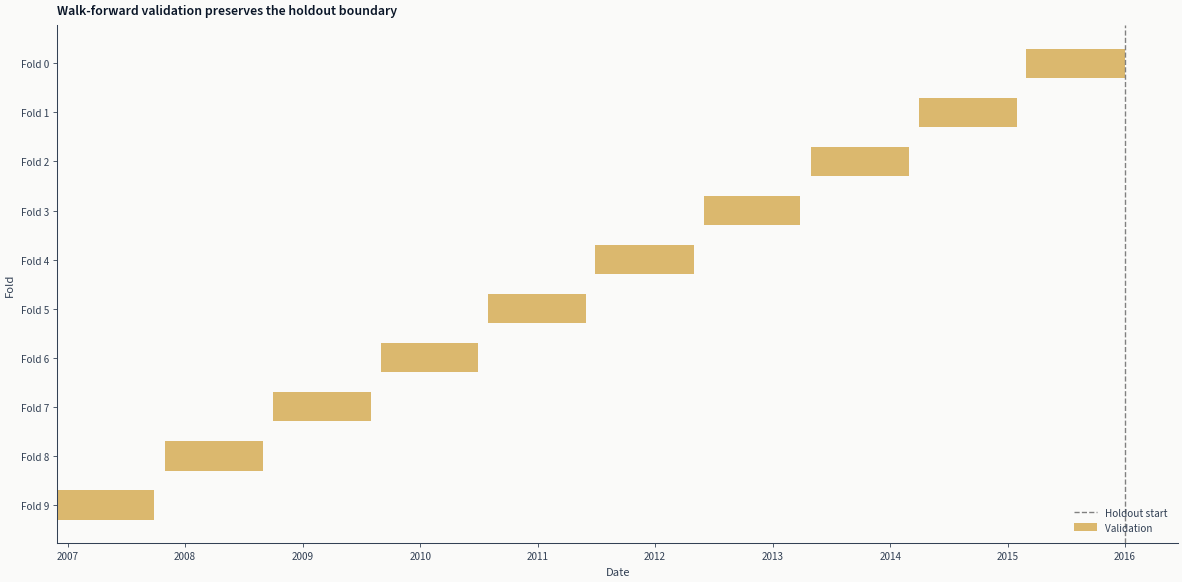

In [9]:
plot_cv_timeline(fold_ranges, n_splits, holdout_start)

Each fold trains on a fixed-length window and validates on the year that follows it,
and the windows step backwards so that the earliest fold index is the most recent
year. The table above gives the exact validation span of each one. The holdout year
declared in the configuration appears in none of them: no model selection anywhere
in this case study, including everything in this notebook, has seen it.

What the timeline buys is a defence against reading a single lucky window as a
result. A model that ranks the cross-section well only in the year credit markets
froze has told you something about that year. Ten separate validation windows,
covering expansion, crisis and recovery, are what let a difference between families
be attributed to the families.

## 2. What Was Actually Run?

Before comparing anything, it is worth writing down what is comparable. The families
were not all trained on all labels, and more importantly they do not all produce the
same kind of number. Three kinds appear in this case study:

- **Predictive.** Linear, GBM and tabular deep learning each map characteristics to
  an expected return and are scored by the rank correlation of that map.
- **Structural.** The latent-factor estimators are fitted to explain the covariance
  and pricing structure of the panel. They also produce a per-name score, and that
  score also gets an information coefficient, but the objective they were fitted
  against is not the ranking.
- **Causal.** Double machine learning estimates the effect of one declared treatment
  on the outcome after orthogonalising a declared set of confounders. Its output is
  an effect size with a standard error, on a different axis entirely.

Forcing all three into one ranking would compare a forecast against a fitted factor
structure against a treatment effect. The coverage map below keeps them apart, and
Section 7 reports the structural and causal evidence on its own terms.

In [10]:
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
SOURCE_NOTEBOOK = {
    "linear": "05_linear",
    "gbm": "06_gbm",
    "tabular_dl": "07_tabular_dl",
    "deep_learning": "07_tabular_dl",
    "latent_factors": "08_latent_factors",
    "causal_dml": "09_causal_dml",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        notebook=pl.col("family").replace(SOURCE_NOTEBOOK),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Which family was fitted on which label:")
print(coverage.select(["notebook", "family", "label", "evidence", "n_configs"]))

Which family was fitted on which label:
shape: (12, 5)
┌───────────────────┬────────────────┬────────────────┬────────────┬───────────┐
│ notebook          ┆ family         ┆ label          ┆ evidence   ┆ n_configs │
│ ---               ┆ ---            ┆ ---            ┆ ---        ┆ ---       │
│ str               ┆ str            ┆ str            ┆ str        ┆ u32       │
╞═══════════════════╪════════════════╪════════════════╪════════════╪═══════════╡
│ 06_gbm            ┆ gbm            ┆ fwd_class_1m   ┆ predictive ┆ 5         │
│ 06_gbm            ┆ gbm            ┆ fwd_ret_1m     ┆ predictive ┆ 15        │
│ 06_gbm            ┆ gbm            ┆ fwd_ret_1m_win ┆ predictive ┆ 15        │
│ 08_latent_factors ┆ latent_factors ┆ fwd_class_1m   ┆ structural ┆ 4         │
│ 08_latent_factors ┆ latent_factors ┆ fwd_ret_1m     ┆ structural ┆ 4         │
│ …                 ┆ …              ┆ …              ┆ …          ┆ …         │
│ 05_linear         ┆ linear         ┆ fwd_ret_1m     

In [11]:
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
labels_by_family = (
    coverage.group_by("family").agg(pl.col("label").n_unique().alias("n_labels")).sort("family")
)
all_labels = sorted(coverage["label"].unique().to_list())

print(f"labels trained anywhere in this case study: {', '.join(all_labels)}")
print(f"families carrying metrics on {PRIMARY_LABEL}: {primary_coverage.height}")
print(labels_by_family)

labels trained anywhere in this case study: fwd_class_1m, fwd_ret_1m, fwd_ret_1m_win
families carrying metrics on fwd_ret_1m: 4
shape: (4, 2)
┌────────────────┬──────────┐
│ family         ┆ n_labels │
│ ---            ┆ ---      │
│ str            ┆ u32      │
╞════════════════╪══════════╡
│ gbm            ┆ 3        │
│ latent_factors ┆ 3        │
│ linear         ┆ 3        │
│ tabular_dl     ┆ 3        │
└────────────────┴──────────┘


Two things in that table shape everything downstream.

The first is which families appear at all. A family with no row here was not fitted
on this panel, and its absence is a statement about what was run rather than a result
about the method. The declared latent-factor list printed at the top of the notebook
is where to check whether an estimator was meant to be here.

The second is the label column. Where a family has been fitted on more than one
label, the same features and the same folds have been asked a slightly different
question: the raw forward return, a winsorized version of it that removes the
influence of extreme moves, and a binary up-or-down classification. Section 6 uses
that to separate a statement about a model from a statement about a label.

The causal family will not appear in this map at all. It writes to a separate table
rather than to the prediction metrics, which is the point of keeping it on its own
axis.

## 3. Headline Comparative View

The comparison below takes the highest-IC configuration in each family on the
primary label and puts a HAC confidence interval around it. The interval matters
more than the point estimate. Monthly cross-sectional ICs are autocorrelated, so a
naive standard error understates the uncertainty; the HAC correction widens it to
something the sample supports.

Read the `covers_zero` column first. A family whose interval covers zero has not
demonstrated a signal on this label, whatever its point estimate happens to be, and
an ordering among such families is an ordering of one sample's noise. Where intervals
do separate, the ordering means something.

In [12]:
family_leaders = (
    all_metrics.filter(pl.col("ic_mean_daily").is_not_null() & (pl.col("ic_se_hac") > 0))
    .sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("family", maintain_order=True)
    .first()
    .select(
        "family",
        "config_name",
        "checkpoint_value",
        "ic_mean_daily",
        "ic_se_hac",
        "ic_t_hac",
        ci_lo=pl.col("ic_mean_daily") - 1.96 * pl.col("ic_se_hac"),
        ci_hi=pl.col("ic_mean_daily") + 1.96 * pl.col("ic_se_hac"),
    )
    .with_columns(covers_zero=(pl.col("ci_lo") <= 0) & (pl.col("ci_hi") >= 0))
    .sort("ic_mean_daily", descending=True)
)
print(f"families compared: {family_leaders.height}")
print(f"intervals covering zero: {family_leaders.get_column('covers_zero').sum()}")
family_leaders

families compared: 4
intervals covering zero: 2


family,config_name,checkpoint_value,ic_mean_daily,ic_se_hac,ic_t_hac,ci_lo,ci_hi,covers_zero
str,str,i64,f64,f64,f64,f64,f64,bool
"""gbm""","""leaves_7_mae""",350,0.08359,0.011804,7.081693,0.060455,0.106725,false
"""tabular_dl""","""tabm_s""",25,0.032013,0.007089,4.515863,0.018118,0.045907,false
"""latent_factors""","""sdf""",512,0.015865,0.01101,1.441036,-0.005714,0.037444,true
"""linear""","""lasso_f0.85""",null,-0.003594,0.01125,-0.319517,-0.025643,0.018455,true


The table above is the notebook's central result and the rest of it is commentary on
how far that result can be pushed.

Where a family's interval excludes zero, the panel carries a cross-sectional signal
that this family finds, and the width of the interval says how precisely. Where it
covers zero, the honest reading is that the highest-IC configuration in that family
is indistinguishable from no signal at all on this label, and its position in the
ordering is not evidence. That reading holds for the structural rows too, with the
extra caveat that a latent-factor estimator was not fitted to maximise this quantity
in the first place.

One asymmetry is worth naming. The leader in each family is selected by the same
statistic the interval is placed around, across as many configurations as that
family declared. The more configurations a family searched, the more the selected
point estimate is flattered by that search, and the interval does not correct for it.
Families with a wide grid should therefore be read a little more sceptically than
families with a narrow one, and the configuration count printed in Section 2 is the
scale of the effect.

### Which Model Families Extract the Most Signal?

A mean across folds hides how it was earned. The next two figures break the same
comparison down by validation window, first as a heatmap of every family against
every fold, then as a distribution.

In [13]:
fold_ic = fold_performance_matrix(best_preds, date_col=DATE_COL)

### Figure 2: Fold-by-Model Performance Heatmap

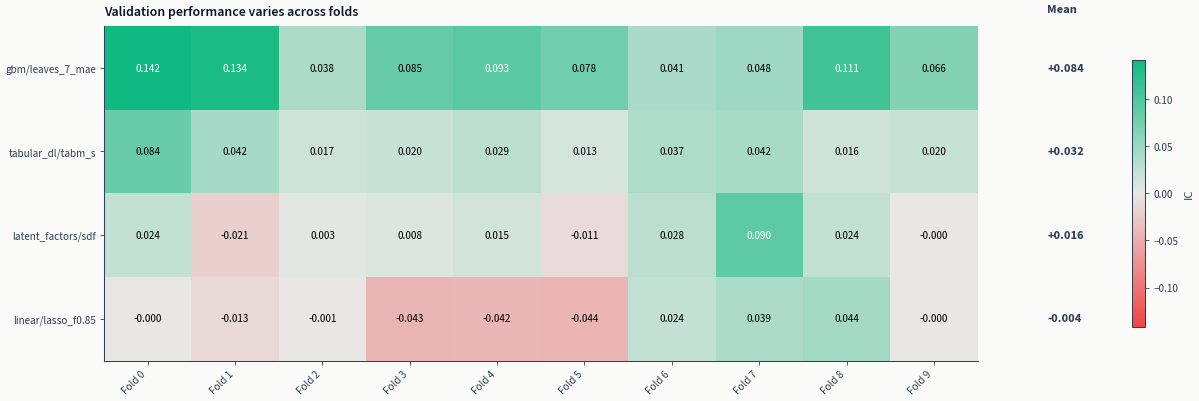

In [14]:
model_labels, fold_cols, matrix = plot_fold_heatmap(fold_ic)

In [15]:
family_stats = (
    fold_ic.group_by("model_label")
    .agg(
        pl.col("ic_mean").mean().alias("mean_ic"),
        pl.col("ic_mean").median().alias("median_ic"),
        pl.col("ic_mean").std().alias("std_ic"),
        pl.col("ic_mean").min().alias("worst_fold"),
        pl.col("ic_mean").max().alias("best_fold"),
        (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
        pl.col("ic_mean").count().alias("n_folds"),
    )
    .sort("mean_ic", descending=True)
)
print(family_stats)

shape: (4, 8)
┌──────────────┬───────────┬───────────┬──────────┬────────────┬───────────┬─────────────┬─────────┐
│ model_label  ┆ mean_ic   ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positiv ┆ n_folds │
│ ---          ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ e           ┆ ---     │
│ str          ┆ f64       ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ ---         ┆ u32     │
│              ┆           ┆           ┆          ┆            ┆           ┆ f64         ┆         │
╞══════════════╪═══════════╪═══════════╪══════════╪════════════╪═══════════╪═════════════╪═════════╡
│ gbm/leaves_7 ┆ 0.08359   ┆ 0.081315  ┆ 0.036869 ┆ 0.038388   ┆ 0.141858  ┆ 1.0         ┆ 10      │
│ _mae         ┆           ┆           ┆          ┆            ┆           ┆             ┆         │
│ tabular_dl/t ┆ 0.032013  ┆ 0.024753  ┆ 0.021155 ┆ 0.012618   ┆ 0.083526  ┆ 1.0         ┆ 10      │
│ abm_s        ┆           ┆           ┆          ┆            ┆           ┆ 

Read the heatmap by column rather than by row. A column is one validation window,
and when a whole column is dark or light together, that window was hard or easy for
every family at once, which is a property of the market in that year rather than of
any model. What distinguishes families is the rows: whether a row holds its sign
across windows, and how far its worst window falls.

The `pct_positive` column in the table is the blunt version of the same question. A
family that is positive in most windows has something that survives regime change; a
family that is positive in half of them is describing a coin flip however large its
mean, because with ten folds a fifty-fifty split is exactly what no signal looks
like.

## 4. Stability Over Time

The mean IC and the fold-level record can disagree, and when they do the fold-level
record is the one that predicts what a deployed strategy would have felt. A family
whose average is carried by two exceptional windows spends the other eight
disappointing whoever is trading it.

### Figure 3: Fold Performance Distribution by Model Family

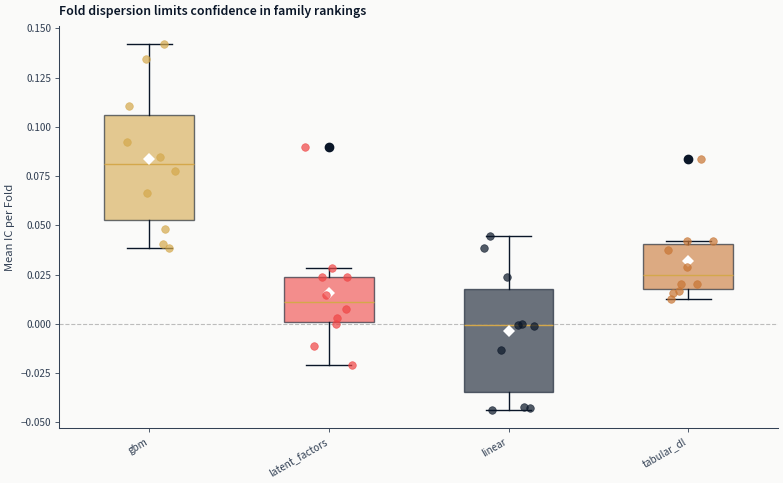

In [16]:
plot_fold_boxplot(fold_ic)

In [17]:
stability = (
    fold_ic.group_by("model_label")
    .agg(
        pl.col("ic_mean").median().alias("median_fold_ic"),
        (pl.col("ic_mean") > 0).sum().alias("folds_positive"),
        pl.col("ic_mean").count().alias("folds"),
        pl.col("ic_mean").min().alias("worst_fold_ic"),
    )
    .with_columns(majority_positive=pl.col("folds_positive") * 2 > pl.col("folds"))
    .sort("median_fold_ic", descending=True)
)
print(f"families with a positive median fold IC: {(stability['median_fold_ic'] > 0).sum()}")
print(f"families positive in a majority of folds: {stability['majority_positive'].sum()}")
stability

families with a positive median fold IC: 3
families positive in a majority of folds: 3


model_label,median_fold_ic,folds_positive,folds,worst_fold_ic,majority_positive
str,f64,u32,u32,f64,bool
"""gbm/leaves_7_mae""",0.081315,10,10,0.038388,true
"""tabular_dl/tabm_s""",0.024753,10,10,0.012618,true
"""latent_factors/sdf""",0.011194,7,10,-0.020898,true
"""linear/lasso_f0.85""",-0.000574,3,10,-0.043661,false


The box plot and the table answer different halves of the stability question. The box
shows the spread, which is what a position-sizing rule has to absorb; the table shows
how often the sign was right, which is what a decision to trade the signal at all
rests on.

A wide box with a positive median is a signal you would size down but still take. A
narrow box centred on zero is not a signal at all, however tidy it looks. And a
family whose worst fold is far below every other family's worst fold has a tail that
a backtest over a different decade would have found, which is the argument for
reading `worst_fold_ic` next to the median rather than after it.

## 5. What Are the Models Learning?

Aggregate IC says a ranking is better than chance. It does not say whether the
ranking is usable. Two further diagnostics decide that:

1. **Monotonicity.** Sorting names into deciles by predicted score, does realised
   return rise across the deciles? A long-short decile portfolio only works if it
   does, and the size of the gap between the top and bottom decile is what has to
   cover trading costs.
2. **Diversity.** Do the families rank the cross-section differently, or do they
   agree? Two models that produce nearly the same ordering are one model for the
   purpose of combining them.

In [18]:
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask)
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity


Top-bottom bucket spread vs trading costs (5–20 bps per leg):
  gbm                   spread=+181 bps  edge/cost=18.1–4.5x
  tabular_dl            spread=+241 bps  edge/cost=24.1–6.0x
  latent_factors        spread=+192 bps  edge/cost=19.2–4.8x
  linear                spread=+95 bps  edge/cost=9.5–2.4x


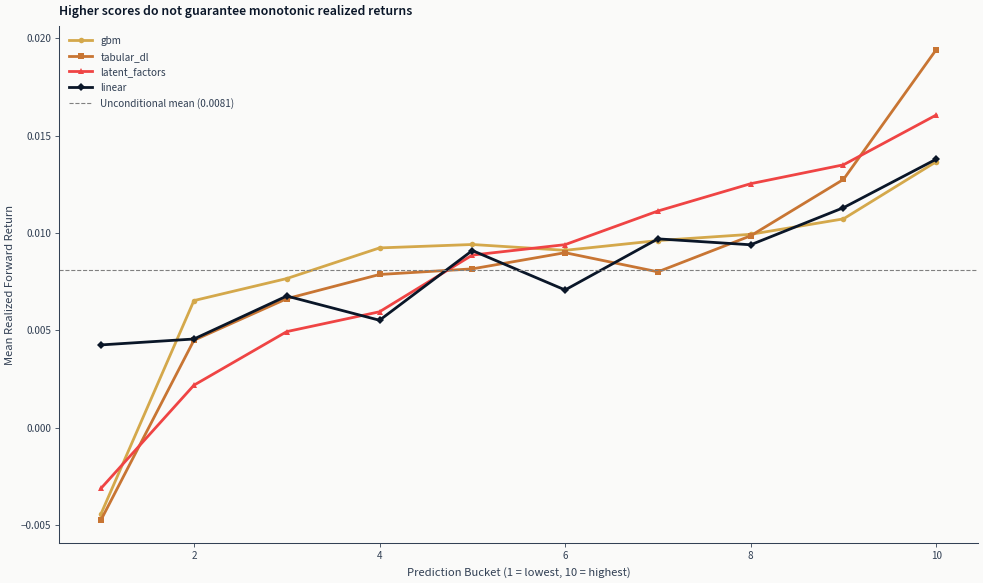

In [19]:
unconditional_mean = float(best_preds["y_true"].mean())
plot_bucket_monotonicity(
    bucket_results, N_BUCKETS, unconditional_mean=unconditional_mean, cost_range=cost_range
)

In [20]:
round_trip_lo, round_trip_hi = 2 * cost_range[0], 2 * cost_range[1]
spread_rows = []
for family, buckets in bucket_results.items():
    top = buckets.filter(pl.col("bucket") == N_BUCKETS)["mean_return"]
    bottom = buckets.filter(pl.col("bucket") == 1)["mean_return"]
    if top.len() == 0 or bottom.len() == 0:
        continue
    spread_bps = (top[0] - bottom[0]) * 10_000
    spread_rows.append(
        {
            "family": family,
            "top_decile_bps": top[0] * 10_000,
            "bottom_decile_bps": bottom[0] * 10_000,
            "spread_bps": spread_bps,
            "clears_low_cost": spread_bps > round_trip_lo,
            "clears_high_cost": spread_bps > round_trip_hi,
        }
    )

decile_spreads = pl.DataFrame(spread_rows).sort("spread_bps", descending=True)
print(f"round-trip cost assumption: {round_trip_lo} to {round_trip_hi} bps per rebalance")
print(f"families whose spread clears the low-cost end: {decile_spreads['clears_low_cost'].sum()}")
print(f"families whose spread clears the high-cost end: {decile_spreads['clears_high_cost'].sum()}")
decile_spreads

round-trip cost assumption: 10 to 40 bps per rebalance
families whose spread clears the low-cost end: 4
families whose spread clears the high-cost end: 4


family,top_decile_bps,bottom_decile_bps,spread_bps,clears_low_cost,clears_high_cost
str,f64,f64,f64,bool,bool
"""tabular_dl""",194.212495,-47.123721,241.336216,true,true
"""latent_factors""",160.633125,-30.96769,191.600815,true,true
"""gbm""",136.667252,-43.977067,180.644319,true,true
"""linear""",137.962319,42.597617,95.364702,true,true


The spread is a gross number and the cost columns are what turn it into a claim about
a tradeable strategy. A family that clears the low-cost end but not the high-cost end
is saying that whether this signal pays depends on which names it trades: liquid
large caps at the cheap end of the declared range, or the small illiquid names where
the per-leg assumption doubles.

Monotonicity across the middle deciles is a separate question from the size of the
gap, and the figure is where to read it. A model that separates the extremes while
scrambling the middle has learned to spot the tails of the cross-section, which is a
narrower and more fragile thing than ranking it. The comparison against the
unconditional mean drawn on the figure is what shows whether the long leg carries the
spread, the short leg does, or both.

In [21]:
corr_matrix, corr_labels = prediction_correlation_matrix(
    best_preds, date_col=DATE_COL, entity_col=ENTITY_COL
)

### Figure 5: Prediction Correlation Across Models


Average pairwise correlation: 0.19
Range: -0.00 to 0.33


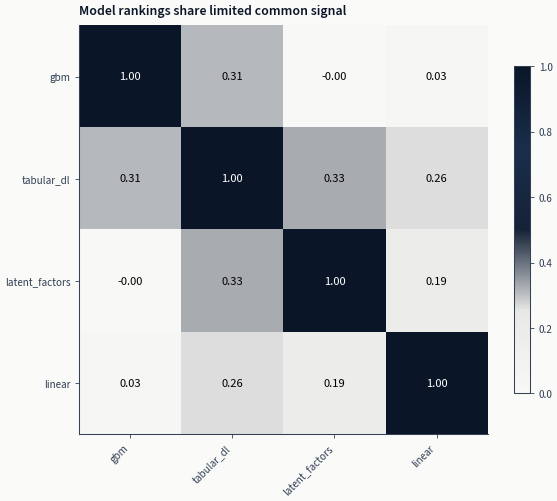

In [22]:
plot_correlation_matrix(corr_matrix, corr_labels)

The correlation matrix is the input to any decision about combining families.
A pair whose predictions correlate weakly is offering genuinely different views of
the same month, so averaging them cancels some error without giving up much mean.
A pair that correlates strongly is offering one view twice, and the more expensive
member of the pair is paying for something the cheaper one already had.

The reason to expect diversity here is that the families disagree about what shape
the mapping from characteristics to returns has. A penalised linear model commits to
one global linear combination. A boosted tree ensemble builds a step function out of
thresholds on individual characteristics and their interactions. The tabular network
learns smooth transformations of each feature before mixing them. A latent-factor
estimator does not model the return directly at all: it fits a small factor structure
to the panel and scores a name by its exposure. Those are different inductive biases
applied to identical inputs, so where their predictions agree, they agree because the
data forced them to.

### How Much Does Additional Model Complexity Help?

Families that publish intermediate checkpoints let us watch validation IC as training
proceeds, which is where the tradeoff between capacity and overfitting becomes
visible rather than assumed.

In [23]:
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)
print(f"families publishing more than one checkpoint: {cp_families}")

families publishing more than one checkpoint: ['gbm', 'tabular_dl', 'latent_factors']


### Figure 6: Learning Curves

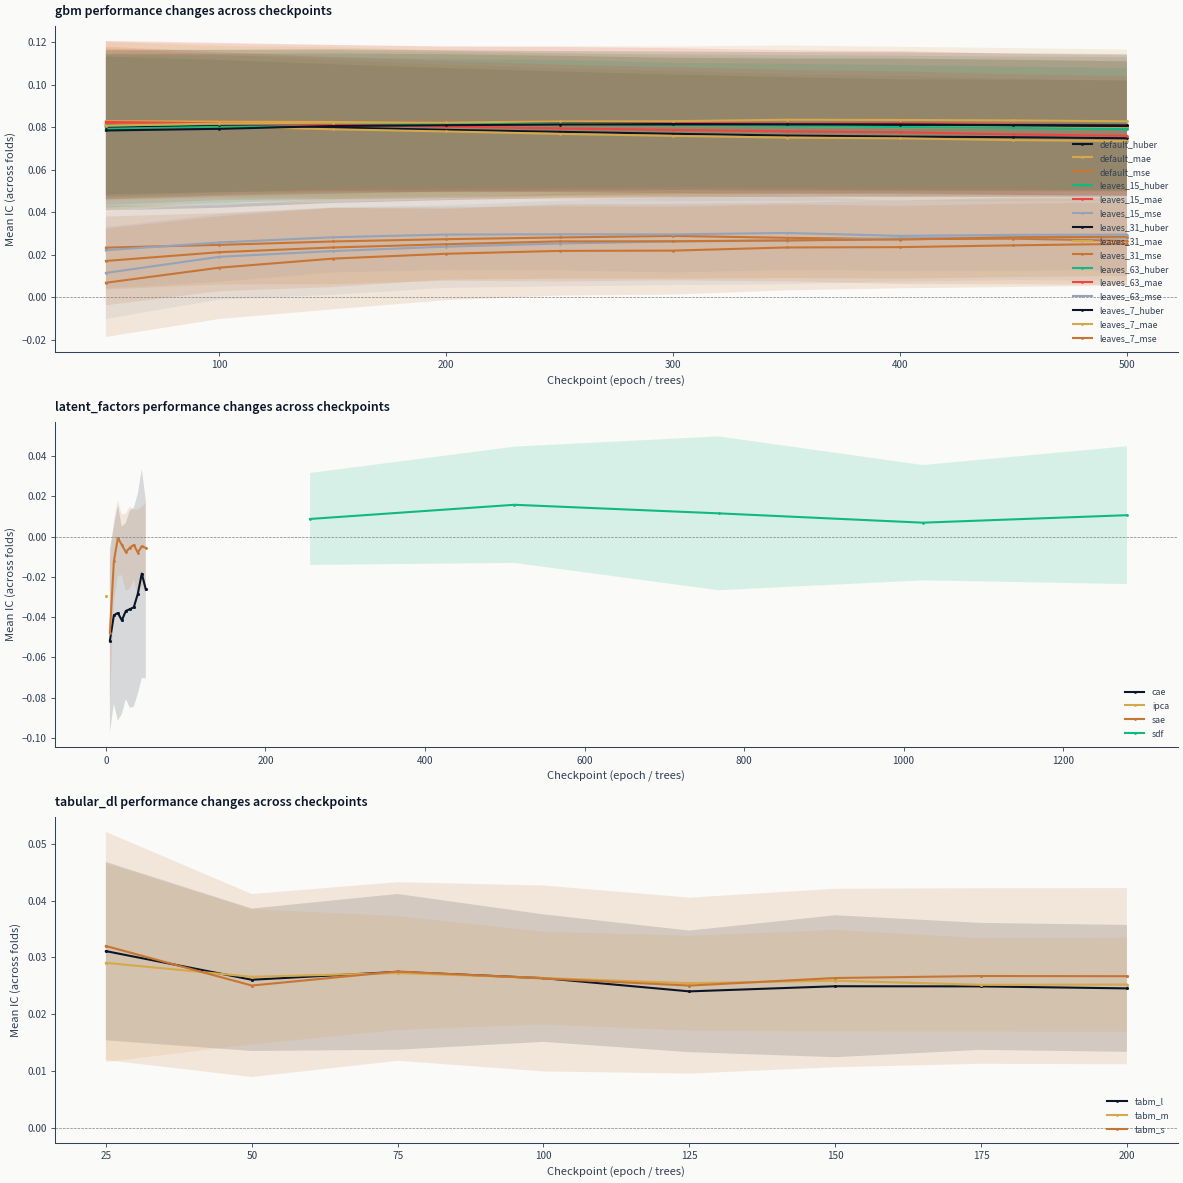

In [24]:
plot_learning_curves(cp_data, cp_families)

There are three shapes to look for and they call for different actions.

A curve that rises and then flattens says the extra capacity is being spent on
nothing: the cheapest checkpoint on the plateau is the one to keep, and training
longer only costs compute. A curve that rises and then falls says the model has
started to fit fold-specific noise, and where it turns over is where early stopping
belongs. A curve that is flat from the first checkpoint says whatever the family was
going to find, it found immediately, which is the usual shape for estimators fitted
to a structural objective rather than to validation IC.

The checkpoint axis is not comparable across families. A boosting iteration, a
training epoch and an alternating-least-squares pass are different units of work, so
these curves are read one family at a time.

### Which Features Drive the Forecasts?

Importance from a single fit is an anecdote. Importance that recurs across ten
walk-forward folds, each fitted on a different decade of data, is evidence that a
characteristic carries something durable rather than something local to one regime.

Where booster files are available this is read directly from the trees. Where they
are not, the fallback below measures the rank correlation between each characteristic
and the leading family's own score, fold by fold. That is a weaker instrument and it
is worth being precise about why: it says what the model's ranking co-moves with, not
what the model uses. A characteristic that is highly correlated with a feature the
model actually relies on will score just as highly as the feature itself.

In [25]:
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)
importance_source = "gbm booster gain"

if gbm_importance is None:
    leader = family_leaders.row(0, named=True)
    leader_family, leader_config = leader["family"], leader["config_name"]
    importance_source = f"rank correlation with {leader_family}/{leader_config} scores"
    print(f"No booster files published. Falling back to {importance_source}.")

    features_df = pl.read_parquet(features_path)
    if features_df[DATE_COL].dtype == pl.String:
        features_df = features_df.with_columns(pl.col(DATE_COL).str.to_datetime())
    # The feature parquet and the prediction parquets disagree on both the type and the
    # time unit of the timestamp, and a join across two datetime units raises rather
    # than casting, so pin the feature side to whatever the predictions carry.
    features_df = features_df.with_columns(pl.col(DATE_COL).cast(best_preds[DATE_COL].dtype))

    leader_preds = best_preds.filter(
        (pl.col("family") == leader_family) & (pl.col("config_name") == leader_config)
    )
    merged = leader_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

    importance_rows = []
    for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
        fold_data = merged.filter(pl.col("fold_id") == fold)
        for feat in feature_cols:
            vals = fold_data[[feat, "y_score"]].drop_nulls()
            if vals.height > 50:
                corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                importance_rows.append(
                    {
                        "config_name": leader_config,
                        "fold_id": int(fold),
                        "feature": feat,
                        "importance": abs(float(corr)),
                    }
                )

    if importance_rows:
        gbm_importance = pl.DataFrame(importance_rows).with_columns(
            (
                pl.col("importance") / pl.col("importance").max().over(["config_name", "fold_id"])
            ).alias("importance_norm")
        )
        top_features = (
            gbm_importance.group_by("feature")
            .agg(pl.col("importance_norm").mean().alias("mean_imp"))
            .sort("mean_imp", descending=True)
            .head(TOP_N_FEATURES)["feature"]
            .to_list()
        )
        gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))

if gbm_importance is not None and gbm_importance.height > 0:
    print(f"importance source: {importance_source}")
    print(
        f"{gbm_importance['feature'].n_unique()} characteristics across "
        f"{gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("No feature importance could be computed for this case study.")

No booster files published. Falling back to rank correlation with gbm/leaves_7_mae scores.


importance source: rank correlation with gbm/leaves_7_mae scores
15 characteristics across 10 folds


### Figure 7: Feature Importance Stability Heatmap


Persistent features (top-5 in ≥75% of folds): ['Resid_Var', 'Spread', 'Variance', 'IdioVol']


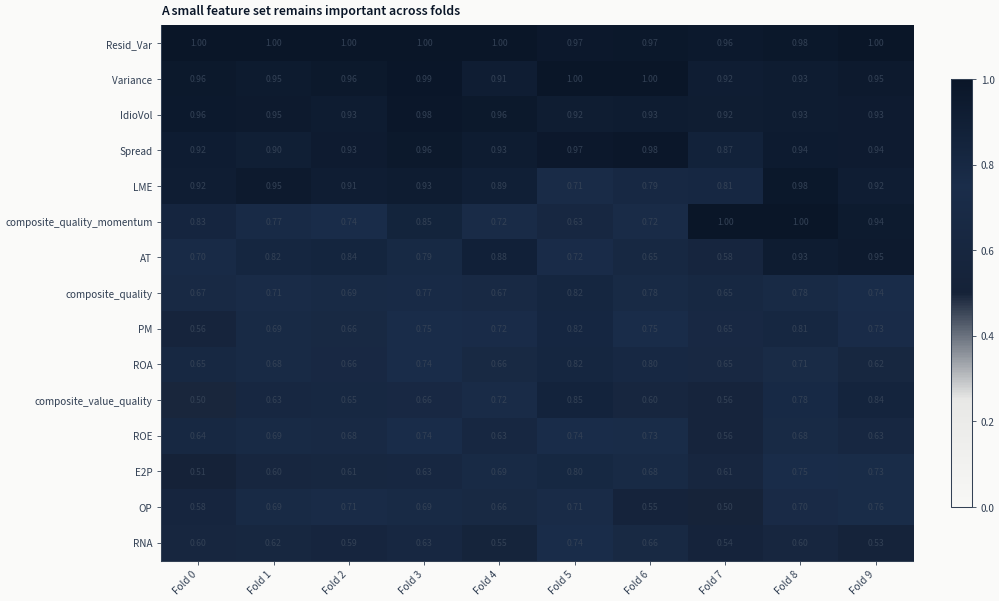

In [26]:
plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)

In [27]:
if gbm_importance is not None and gbm_importance.height > 0:
    n_folds_imp = gbm_importance["fold_id"].n_unique()
    top5_per_fold = (
        gbm_importance.sort(["fold_id", "importance_norm"], descending=[False, True])
        .group_by("fold_id", maintain_order=True)
        .head(5)
    )
    persistence = (
        top5_per_fold.group_by("feature")
        .agg(pl.len().alias("folds_in_top5"))
        .with_columns(share_of_folds=pl.col("folds_in_top5") / n_folds_imp)
        .sort("folds_in_top5", descending=True)
    )
    print(
        f"characteristics reaching the top five in at least one of {n_folds_imp} folds: "
        f"{persistence.height}"
    )
    print(
        f"characteristics in the top five in every fold: "
        f"{(persistence['folds_in_top5'] == n_folds_imp).sum()}"
    )
    persistence.head(10)

characteristics reaching the top five in at least one of 10 folds: 9
characteristics in the top five in every fold: 2


A characteristic that reaches the top five in nearly every fold is doing the same
work across ten different training decades, which is the strongest statement this
diagnostic can make. One that appears in a single fold is describing that fold.

The count of characteristics that ever reach the top five is itself informative. If
it is close to five, the same handful drives the ranking everywhere and the rest of
the feature set is doing little; if it is much larger, importance rotates with the
regime and no small subset would have served across the whole sample.

## 6. Heterogeneity: Labels and Regimes

The same features and folds were used to answer more than one question. The forest
plot below restricts to the regression labels, because a classification label is
scored on a different axis and folding an AUC into an IC panel would compare two
different things on one line.

In [28]:
regression_labels = [
    lbl
    for lbl in [setup["labels"]["primary"], *setup["labels"]["variants"]]
    if not lbl.startswith("fwd_class")
]
multi_rows = []
for lbl in regression_labels:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_1m""","""latent_factors""","""sdf""",0.015865,-0.005955,0.037686,1.441036
"""fwd_ret_1m""","""gbm""","""leaves_7_mae""",0.08359,0.060195,0.106984,7.081693
"""fwd_ret_1m""","""linear""","""lasso_f0.85""",-0.003594,-0.025891,0.018702,-0.319517
"""fwd_ret_1m""","""tabular_dl""","""tabm_s""",0.032013,0.017963,0.046063,4.515863
"""fwd_ret_1m_win""","""tabular_dl""","""tabm_s""",0.043142,0.028835,0.05745,5.97647
"""fwd_ret_1m_win""","""linear""","""lasso_f0.2""",0.029216,0.011334,0.047097,3.238234
"""fwd_ret_1m_win""","""latent_factors""","""cae""",0.026351,0.002474,0.050228,2.187307
"""fwd_ret_1m_win""","""gbm""","""leaves_7_mae""",0.083489,0.06061,0.106368,7.232603


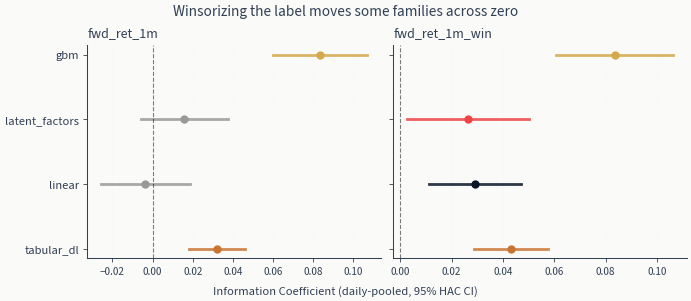

In [29]:
plot_label_horizon_forest(
    multi_label_df,
    families=sorted(all_labels_metrics["family"].unique().to_list()),
    labels=regression_labels,
    label_display={lbl: lbl for lbl in regression_labels},
    title="Winsorizing the label moves some families across zero",
)

In [30]:
label_evidence = (
    multi_label_df.filter(pl.col("ic_ci_lo").is_not_null() & pl.col("ic_ci_hi").is_not_null())
    .with_columns(excludes_zero=(pl.col("ic_ci_lo") > 0) | (pl.col("ic_ci_hi") < 0))
    .sort("ic_mean_daily", descending=True, nulls_last=True)
)
by_label = (
    label_evidence.group_by("label")
    .agg(
        pl.len().alias("families"),
        pl.col("excludes_zero").sum().alias("intervals_excluding_zero"),
    )
    .sort("label")
)
print(f"{label_evidence.height} label-and-family pairs carry an interval")
print(f"{label_evidence['excludes_zero'].sum()} of them exclude zero")
print(by_label)
label_evidence.select(
    "label", "family", "config_name", "ic_mean_daily", "ic_ci_lo", "ic_ci_hi", "excludes_zero"
)

8 label-and-family pairs carry an interval
6 of them exclude zero
shape: (2, 3)
┌────────────────┬──────────┬──────────────────────────┐
│ label          ┆ families ┆ intervals_excluding_zero │
│ ---            ┆ ---      ┆ ---                      │
│ str            ┆ u32      ┆ u32                      │
╞════════════════╪══════════╪══════════════════════════╡
│ fwd_ret_1m     ┆ 4        ┆ 2                        │
│ fwd_ret_1m_win ┆ 4        ┆ 4                        │
└────────────────┴──────────┴──────────────────────────┘


label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,excludes_zero
str,str,str,f64,f64,f64,bool
"""fwd_ret_1m""","""gbm""","""leaves_7_mae""",0.08359,0.060195,0.106984,true
"""fwd_ret_1m_win""","""gbm""","""leaves_7_mae""",0.083489,0.06061,0.106368,true
"""fwd_ret_1m_win""","""tabular_dl""","""tabm_s""",0.043142,0.028835,0.05745,true
"""fwd_ret_1m""","""tabular_dl""","""tabm_s""",0.032013,0.017963,0.046063,true
"""fwd_ret_1m_win""","""linear""","""lasso_f0.2""",0.029216,0.011334,0.047097,true
"""fwd_ret_1m_win""","""latent_factors""","""cae""",0.026351,0.002474,0.050228,true
"""fwd_ret_1m""","""latent_factors""","""sdf""",0.015865,-0.005955,0.037686,false
"""fwd_ret_1m""","""linear""","""lasso_f0.85""",-0.003594,-0.025891,0.018702,false


The comparison to make here is within a family and across labels. Where a family's
interval excludes zero on one label and covers zero on another, the label is doing
work the model could not do: winsorizing pulls in the extreme monthly returns that
dominate a squared-error objective, and a family that was being pulled around by
those observations gets a cleaner target to fit.

That has a direct consequence for what gets traded. A signal that only clears zero on
the winsorized label is a signal about the bulk of the cross-section, and the
strategy that uses it should be the one that trades the bulk. Reading it as evidence
for the raw-return label would be borrowing credibility from a different question.

Where a family's interval behaves the same way on both labels, the opposite follows:
whatever robustness winsorizing supplies, that family already had, most often because
its own loss function was already insensitive to the tails.

### Regime-Conditional Performance

Cross-sectional predictability is not constant. When stocks move together there is
little to rank; when they separate, the same model has more to work with. The split
below measures the dispersion of realised returns within each month and calls the
months above the sample median high-dispersion. That is a split of this sample rather
than a regime label a trader could have applied at the time, so it diagnoses where a
family's signal lives; it does not define a rule for switching between families.

In [31]:
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask)
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_results.append(regime_ic.with_columns(pl.lit(family).alias("family")))

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

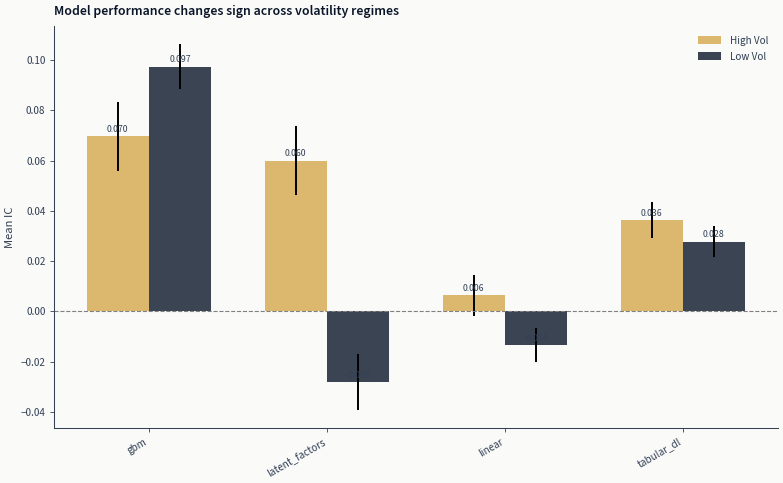

In [32]:
plot_regime_bars(regime_df)

A family whose bars are similar across regimes has a signal that does not depend on
the market being agitated, which is the more comfortable thing to deploy. A family
whose signal lives entirely in the high-dispersion bar is telling you that its mean
IC was earned in a minority of months, and that a strategy built on it will spend
most of its life flat and occasionally do all its work at once.

The regime split is also a check on the fold record in Section 4. If one family's
weak folds are exactly the low-dispersion years, then the two diagnostics are
describing one phenomenon rather than two, and sizing by realised dispersion is the
natural response.

## 7. Structural and Causal Evidence

The latent-factor and causal families produce numbers that a table will happily print
next to an IC and that mean something else. This section reports each on its own
terms.

### Latent Factors

The estimators declared for this panel are printed at the top of the notebook. Each
fits a small factor structure to the cross-section and then scores a name by its
exposure to those factors. Two of them, the conditional autoencoder and the
supervised autoencoder, are neural; IPCA maps characteristics to factor loadings
linearly; the stochastic discount factor estimator fits a pricing kernel and reports
its own Sharpe ratio as an internal diagnostic.

Their scores appear in the IC comparison above because they can be scored that way,
not because that is the objective they were fitted against. An estimator whose
interval covers zero there has still fitted the factor structure it was asked to fit;
what it has not done is produce a cross-sectional ranking the panel supports.

In [33]:
# The per-fold diagnostics are keyed by training hash, so the config name from the
# metrics table has to be resolved to the hash of the run that produced it.
lf_runs = (
    all_metrics.filter(pl.col("family") == "latent_factors")
    .sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("config_name", maintain_order=True)
    .first()
    .select("config_name", "training_hash", "ic_mean_daily")
    .sort("ic_mean_daily", descending=True, nulls_last=True)
)

lf_extras = {}
for row in lf_runs.iter_rows(named=True):
    extras = load_fold_extras(CASE_STUDY, row["training_hash"])
    if extras:
        lf_extras[row["config_name"]] = extras

print("Latent-factor estimators fitted on this label:")
print(lf_runs)
print(f"\nper-fold diagnostics recovered for: {sorted(lf_extras)}")
missing_extras = sorted(set(lf_runs["config_name"]) - set(lf_extras))
if missing_extras:
    print(f"no fold_extras.json written by: {missing_extras}")

Latent-factor estimators fitted on this label:
shape: (4, 3)
┌─────────────┬───────────────┬───────────────┐
│ config_name ┆ training_hash ┆ ic_mean_daily │
│ ---         ┆ ---           ┆ ---           │
│ str         ┆ str           ┆ f64           │
╞═════════════╪═══════════════╪═══════════════╡
│ sdf         ┆ b120699a460a  ┆ 0.015865      │
│ sae         ┆ 46dae6d34965  ┆ -0.000703     │
│ cae         ┆ b5d1137cf555  ┆ -0.018339     │
│ ipca        ┆ 34412df2e67c  ┆ -0.029662     │
└─────────────┴───────────────┴───────────────┘

per-fold diagnostics recovered for: ['cae', 'ipca', 'sae', 'sdf']


#### IPCA Characteristic Loadings

IPCA estimates a matrix that maps each characteristic to a loading on each latent
factor. Reading down a factor's column shows which characteristics that factor is
built out of, which is the closest thing the latent-factor family offers to the
feature-importance question asked in Section 5.

gamma: 58 characteristics x 5 factors, fold 9
converged: True after 28 iterations


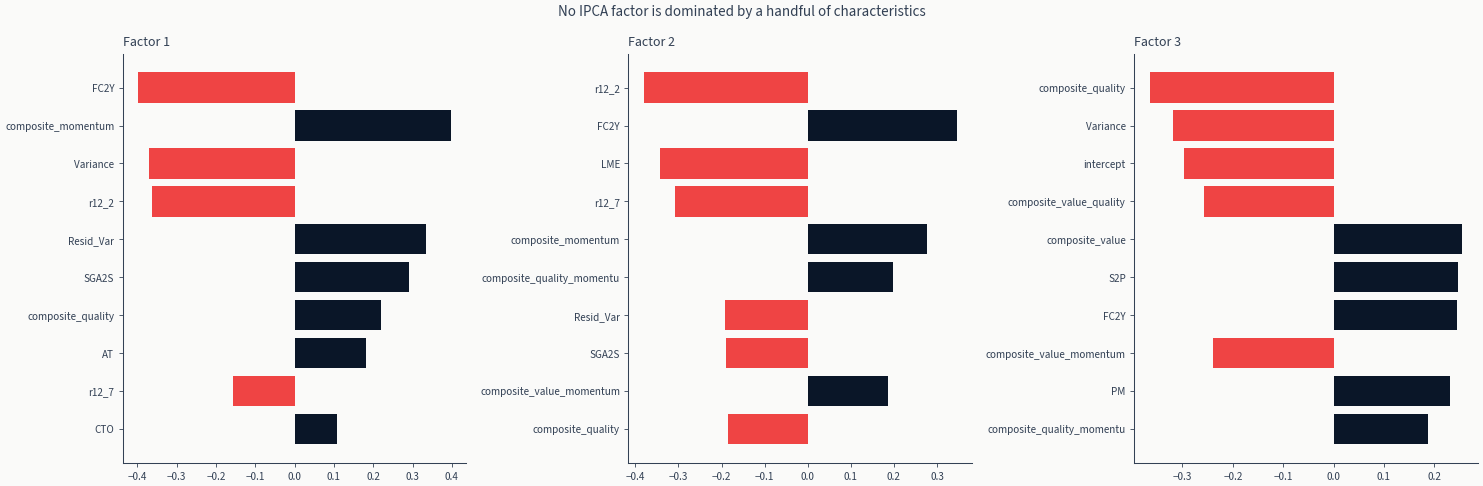

In [34]:
if "ipca" in lf_extras:
    last_fold = lf_extras["ipca"][-1]
    gamma = np.array(last_fold["gamma"])
    n_chars, n_factors = gamma.shape
    print(f"gamma: {n_chars} characteristics x {n_factors} factors, fold {last_fold['fold_id']}")
    print(f"converged: {last_fold['converged']} after {last_fold['iterations']} iterations")

    # The estimator prepends an intercept column to the characteristics before fitting
    # (ml4t.models.latent_factors.ipca._augment_chars), so gamma has one more row than
    # the feature file has columns and every characteristic sits one row lower than its
    # position in the feature list.
    instrument_names = ["intercept", *feature_cols]
    if len(instrument_names) != n_chars:
        raise ValueError(
            f"gamma carries {n_chars} instruments but the feature file plus an intercept "
            f"gives {len(instrument_names)}; the loadings cannot be labelled"
        )

    n_top = min(10, n_chars)
    n_panels = min(3, n_factors)
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
    axes = np.atleast_1d(axes)
    for k, ax in enumerate(axes):
        col = gamma[:, k]
        top_idx = np.argsort(np.abs(col))[-n_top:][::-1]
        names = [instrument_names[i][:25] for i in top_idx]
        vals = col[top_idx]
        ax.barh(
            range(n_top),
            vals,
            color=[COLORS["blue"] if v > 0 else COLORS["negative"] for v in vals],
        )
        ax.set_yticks(range(n_top))
        ax.set_yticklabels(names, fontsize=8)
        ax.set_title(f"Factor {k + 1}")
        ax.invert_yaxis()
    fig.suptitle("No IPCA factor is dominated by a handful of characteristics")
    fig.tight_layout()
else:
    print("IPCA published no fold diagnostics for this label.")

The loadings describe the factor structure IPCA found; they do not by themselves say
the structure predicts returns. That question is settled by IPCA's interval in
Section 3, and the two answers are independent: a factor model can describe the
covariance of the panel well while ranking next month's returns no better than
chance.

#### Autoencoder Training Convergence

The two autoencoder estimators record a training loss per epoch per fold. Ten curves
that fall and settle in the same place mean the optimisation is doing the same thing
in every decade of the sample, which is what has to be true before any fold-to-fold
difference in IC can be attributed to the data rather than to the fit.

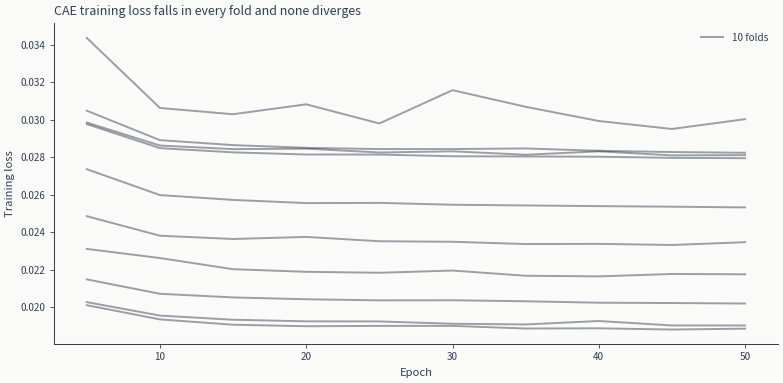

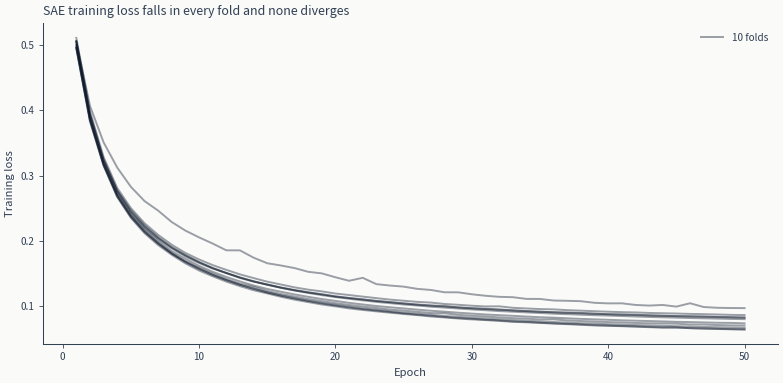

In [35]:
for model_name in ["cae", "sae"]:
    if model_name not in lf_extras:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    plotted = 0
    for fold in lf_extras[model_name]:
        # CAE writes two record shapes into one history: per-epoch training points, and
        # checkpoint records that carry a validation loss and no training loss.
        history = [point for point in (fold.get("train_history") or []) if "train_loss" in point]
        if not history:
            continue
        epochs = [point["epoch"] for point in history]
        losses = [point["train_loss"] for point in history]
        ax.plot(epochs, losses, alpha=0.4, color=COLORS["blue"])
        plotted += 1
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training loss")
    ax.set_title(f"{model_name.upper()} training loss falls in every fold and none diverges")
    ax.legend([f"{plotted} folds"], loc="upper right")
    fig.tight_layout()

#### Stochastic Discount Factor Sharpe Ratios

In [36]:
if "sdf" in lf_extras:
    sharpes = [e["sdf_sharpe"] for e in lf_extras["sdf"] if e.get("sdf_sharpe") is not None]
    if sharpes:
        print(f"SDF in-sample Sharpe across {len(sharpes)} folds:")
        print(f"  mean {np.mean(sharpes):.3f}, std {np.std(sharpes):.3f}")
        print(f"  range {min(sharpes):.3f} to {max(sharpes):.3f}")
else:
    print("SDF published no fold diagnostics for this label.")

SDF in-sample Sharpe across 10 folds:
  mean 1.969, std 0.251
  range 1.685 to 2.410


The Sharpe ratio above is the estimator's own objective evaluated on the data it was
fitted to, not a tradeable result. It belongs here as a convergence check: an
estimator that reports a stable kernel Sharpe across all ten folds has solved the
same problem each time. Whether that kernel ranks next month's cross-section is the
separate question answered by the SDF row in Section 3, and the two can disagree
without either being wrong.

### Causal DML

[`09_causal_dml`](09_causal_dml.ipynb) asks a different question from every other
notebook in this case study. Rather than ranking stocks, it estimates the effect of
one declared treatment characteristic on the forward return, after using machine
learning to partial out a declared set of confounders from both. The output is an
effect size with a standard error, plus a permutation-based refutation test, and it
is stored in its own registry table for that reason.

A causal identity covers the row cap and the development window as well as the fold
and placebo geometry, so re-running under a different cap writes a second row rather
than replacing the first. Both rows are real runs, and the table below is read as this
case study's causal evidence, so it shows the run under the configuration currently
declared and counts the superseded identities rather than mixing them in.

In [37]:
declared_causal = load_configs(CASE_STUDY, PRIMARY_LABEL, "causal_dml")[0]
with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as conn:
    conn.row_factory = sqlite3.Row
    causal_rows = [
        dict(r)
        for r in conn.execute(
            "SELECT label, treatment, dml_effect, dml_se_hac, p_value_hac, naive_effect, "
            "       confounding_bias_pct, refutation_p, n_folds, n_obs, spec_json "
            "FROM causal_runs ORDER BY label"
        ).fetchall()
    ]

if causal_rows:
    all_causal = pl.DataFrame(causal_rows).with_columns(
        config_name=pl.col("spec_json").str.json_path_match("$.config_name"),
        max_samples=pl.col("spec_json").str.json_path_match("$.params.max_samples").cast(pl.Int64),
    )
    causal_df = (
        all_causal.filter(pl.col("config_name") == declared_causal["config_name"])
        .drop("spec_json")
        .with_columns(
            significant_hac=pl.col("p_value_hac") < 0.05,
            refutation_passes=pl.col("refutation_p") < 0.05,
        )
    )
    print(f"declared causal configuration: {declared_causal['config_name']}")
    print(f"runs recorded under it: {causal_df.height}")
    print(f"superseded identities also in the table: {all_causal.height - causal_df.height}")
    print(f"clearing the HAC inference gate: {causal_df['significant_hac'].sum()}")
    print(f"clearing the placebo refutation gate: {causal_df['refutation_passes'].sum()}")
    causal_df
else:
    print("No causal_runs rows recorded for this case study.")

declared causal configuration: dml_250k
runs recorded under it: 1
superseded identities also in the table: 2
clearing the HAC inference gate: 0
clearing the placebo refutation gate: 0


Two gates have to be cleared before a causal claim is made, and they fail in
different ways.

The first is inference on the estimate itself, with a standard error that allows for
correlation across firms within a month. The gap between the naive and orthogonalised
estimates, reported above as a confounding-bias percentage, is what the DML procedure
bought: it is how much of the raw association was attributable to the declared
confounders rather than to the treatment. That percentage divides the gap by the
adjusted estimate, so it grows without bound as the adjusted estimate approaches zero
and says nothing on its own about how large either effect is. Read it beside the two
effect sizes in the table above, which are in the same units as each other.

The second is the placebo test, which re-estimates the effect on permuted treatment
histories and asks where the real estimate falls among them. A placebo p-value near
one does not mean the effect is absent; it means the estimate sits at the wrong end
of the placebo distribution to be read as evidence, and the notebook that produced it
says so directly. Neither gate is a substitute for the other, and an estimate that
clears one is not a result.

This is also not an input to the backtest. The predictive families supply the scores
that get traded; the causal estimate is a statement about one characteristic's effect
on returns, conditional on a specific set of confounders, and it neither ranks the
cross-section nor competes for a place in the ranking above.

### Calibration: Are Prediction Intervals Honest?

An information coefficient says whether the ordering is right. It says nothing about
whether a model knows how wrong it is likely to be. Split-conformal prediction (Vovk
and co-authors, 2005; Lei and co-authors, 2018) gives a distribution-free check:
take the absolute residuals from one fold as a calibration sample, read off the
quantile at the nominal level, and use it to build an interval around every
prediction in the remaining folds. If the method is honest, the true label falls
inside that interval at close to the nominal rate.

Two numbers follow. Empirical coverage below nominal means the intervals are too
narrow and the model is overconfident. Empirical coverage above nominal means the
opposite, which is safer but wasteful. Width, reported as a multiple of the standard
deviation of realised returns so families on different scales can be compared, is
what separates two models that both cover correctly: the one with narrower intervals
at the same coverage is saying more.

In [38]:
conformal_df = conformal_coverage_diagnostic(CASE_STUDY, label=PRIMARY_LABEL)
conformal_df

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""gbm""","""leaves_7_mae""",0.8,0.712078,1.958368,223130
"""gbm""","""leaves_7_mae""",0.9,0.832291,2.808634,223130
"""gbm""","""leaves_7_mae""",0.95,0.905329,3.790223,223130
"""latent_factors""","""sdf""",0.8,0.836199,3.386571,223130
"""latent_factors""","""sdf""",0.9,0.941451,5.792251,223130
…,…,…,…,…,…
"""linear""","""lasso_f0.85""",0.9,0.831565,2.838828,223130
"""linear""","""lasso_f0.85""",0.95,0.901174,3.771847,223130
"""tabular_dl""","""tabm_s""",0.8,0.714243,2.007589,223130


In [39]:
if conformal_df.height > 0:
    calibration = (
        conformal_df.with_columns(
            coverage_gap_pp=(pl.col("empirical_coverage") - pl.col("nominal_level")) * 100
        )
        .select(
            "family",
            "config_name",
            "nominal_level",
            "empirical_coverage",
            "coverage_gap_pp",
            "mean_interval_width_frac_std",
        )
        .sort(["nominal_level", "coverage_gap_pp"])
    )
    under = calibration.filter(pl.col("coverage_gap_pp") < 0).height
    print(f"{calibration.height} family-and-level combinations measured")
    print(f"{under} of them cover less often than nominal")
    print(
        "largest shortfall: "
        f"{calibration['coverage_gap_pp'].min():.1f} pp, "
        f"largest excess: {calibration['coverage_gap_pp'].max():.1f} pp"
    )
    calibration

12 family-and-level combinations measured
9 of them cover less often than nominal
largest shortfall: -8.9 pp, largest excess: 4.1 pp


Read the sign of the gap by family first and by level second. A family that
under-covers at every level has a residual distribution with heavier tails than the
calibration quantile assumed, and its intervals should not be used for position
sizing without a correction. A family that over-covers is paying in width for
safety it did not need.

The level pattern is separate and says something about the shape of the residuals
rather than their spread. A family whose gap shrinks as the nominal level rises has
residuals that are worse behaved near the centre of the distribution than in the far
tail, which is the usual signature of a return distribution with a sharp peak.
A family whose gap grows with the level has the opposite problem, and it is the more
serious one, because the far tail is what a risk limit is set against.

## 8. Pre-Backtest Judgment and Handoff

The table below collects the evidence per family into one row each. It deliberately
stops short of a recommendation column: what advances to a backtest is a decision
about cost, capacity and mandate as much as about statistics, and the point of
gathering the evidence in one place is that a reader can make that decision rather
than read one off.

In [40]:
synthesis_rows = []

for row in family_leaders.iter_rows(named=True):
    family, config = row["family"], row["config_name"]
    label_key = f"{family}/{config}"
    fam_folds = fold_ic.filter(pl.col("model_label") == label_key)

    spread = decile_spreads.filter(pl.col("family") == family)["spread_bps"]
    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic": row["ic_mean_daily"],
            "ci_lo": row["ci_lo"],
            "ci_hi": row["ci_hi"],
            "interval_excludes_zero": not row["covers_zero"],
            "folds_positive": int((fam_folds["ic_mean"] > 0).sum()) if fam_folds.height else None,
            "folds": fam_folds.height or None,
            "worst_fold_ic": float(fam_folds["ic_mean"].min()) if fam_folds.height else None,
            "spread_bps": float(spread[0]) if spread.len() else None,
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic", descending=True)
print(f"families with an interval excluding zero: {synthesis['interval_excludes_zero'].sum()}")
print(
    "families with an interval excluding zero and a spread above the low-cost round trip: "
    f"{synthesis.filter(pl.col('interval_excludes_zero') & (pl.col('spread_bps') > round_trip_lo)).height}"
)
synthesis

families with an interval excluding zero: 2
families with an interval excluding zero and a spread above the low-cost round trip: 2


family,config,ic,ci_lo,ci_hi,interval_excludes_zero,folds_positive,folds,worst_fold_ic,spread_bps
str,str,f64,f64,f64,bool,i64,i64,f64,f64
"""gbm""","""leaves_7_mae""",0.08359,0.060455,0.106725,true,10,10,0.038388,180.644319
"""tabular_dl""","""tabm_s""",0.032013,0.018118,0.045907,true,10,10,0.012618,241.336216
"""latent_factors""","""sdf""",0.015865,-0.005714,0.037444,false,7,10,-0.020898,191.600815
"""linear""","""lasso_f0.85""",-0.003594,-0.025643,0.018455,false,3,10,-0.043661,95.364702


### How to read the synthesis

The columns are in the order the evidence should be weighed.

**`interval_excludes_zero` is the first filter and it is not negotiable.** A family
that fails it has not shown a cross-sectional signal on this label. It may still be
worth fitting on another label, and Section 6 is where to look for that, but it does
not go to a backtest on the strength of a point estimate.

**`folds_positive` and `worst_fold_ic` decide how much of it to believe.** These say
whether the interval was earned steadily or in bursts, and how bad the bad years
were. A family that passes the first filter on the back of two extraordinary folds is
a different proposition from one that was positive in nine.

**`spread_bps` decides whether it can be traded.** A statistically credible ranking
whose decile spread sits inside the round-trip cost is a real finding about the panel
and a strategy that loses money. This column is where a signal stops being a
statistics question.

**The causal row is not in this table and does not belong in it.** It answers a
different question with a different output, and Section 7 reports it separately for
that reason.

### How the forecasts are used downstream

- **Decile sorting.** Rank by `y_score` within each month, hold the top decile long
  and the bottom decile short. This is the construction the monotonicity figure was
  drawn for.
- **Score weighting.** Size positions within a decile by the magnitude of the score
  rather than equally, which helps when the score is informative about degree and
  hurts when it is only informative about order.
- **Combination.** Families whose predictions correlate weakly are the candidates for
  averaging, on the evidence in Figure 5 rather than on how different their
  architectures sound.

### What this notebook does not establish

- **Whether the spread survives a real cost model.** The cost columns here apply a
  flat per-leg range to a decile spread. [`13_costs`](13_costs.ipynb) applies a cost
  model that varies with the name and the trade.
- **Whether the portfolio is capacity-constrained.** Decile membership takes no
  account of how much can be traded in a small name without moving it.
- **Whether the short leg is borrowable.** A long-short spread assumes every
  bottom-decile name can be shorted at a reasonable rate, which is exactly where that
  assumption is weakest.
- **Whether the universe is free of survivorship effects.** The filters follow the
  academic convention rather than reconstructing point-in-time index membership.

**Next**: [`11_backtest`](11_backtest.ipynb) simulates trading these predictions,
[`12_portfolio_management`](12_portfolio_management.ipynb) sizes the positions, and
[`15_strategy_analysis`](15_strategy_analysis.ipynb) reports what the strategy did
end to end.

## Key Takeaways

1. **A family comparison is a comparison of intervals.** The `covers_zero` column in
   Section 3 is what separates families that have demonstrated a signal from families
   whose ordering is a property of this sample. Point estimates alone would have
   supported an ordering the intervals do not.
2. **Selection across a configuration grid is not free.** The leader of each family
   was chosen by the statistic its interval is placed around, and a family that
   searched more configurations has a more flattered leader. The configuration counts
   in Section 2 are the size of that effect.
3. **A mean IC and a fold record answer different questions.** Section 4 reports how
   often each family had the sign right and how bad its worst window was, which is
   what a deployed strategy would have experienced.
4. **The label is part of the model.** Winsorizing the target changes which families
   clear zero, so a signal that appears only on the transformed label is a claim
   about the bulk of the cross-section rather than about the raw one.
5. **A structural fit and a ranking are not the same achievement.** The latent-factor
   estimators are scored on an axis they were not fitted for, and their convergence
   diagnostics in Section 7 can look healthy while their IC intervals cover zero.
6. **The causal estimate is on its own axis and has two gates.** HAC inference and
   the placebo refutation are independent, both have to clear, and neither the
   estimate nor its failure changes which predictions go to the backtest.
7. **Statistical credibility is not tradeability.** The decile spread has to clear a
   round trip at the declared cost range before a credible ranking becomes a strategy
   worth simulating.

**Next**: [`11_backtest`](11_backtest.ipynb) turns these predictions into simulated
trades.